# 03 Politeness Scoring
**Project:** Quantifying Politeness in Online Educational Forums  
**Author:** Karan Raman  
**Purpose:** We first validate both on a sample, then choose the best method to score all posts. 
Score each forum post for politeness using two approaches:
1. **Rule-based** ConvoKit PolitenessStrategies 
2. **Transformer-based** fine-tuned BERT model  

**Run After:** 02_preprocessing.ipynb
**Input:** data/processed/posts_cleaned.parquet
**Output:** data/processed/posts_scored.parquet

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
mpl.rcParams.update({
    'figure.figsize'    : (10, 6),
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.alpha'        : 0.3,
})

BLUE, RED, GREEN, GREY = '#2166AC', '#D6604D', '#1A9641', '#878787'
sns.set_palette([BLUE, RED, GREEN, GREY, '#F4A582'])

DATA_PROCESSED = Path('../data/processed')
DATA_OUT       = Path('../data/outputs')
DATA_OUT.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE = 500
RANDOM_SEED = 42

print('Setup complete.')

Setup complete.


## 1. Load clean data & draw sample

In [2]:
df = pd.read_parquet(DATA_PROCESSED / 'posts_clean.parquet')

In [3]:
sample = df.sample(n=500, random_state=42).reset_index(drop=True)
print(f'Sample size: {len(sample)}')
print(sample[['text_clean', 'course_type', 'is_question']].head(3))

Sample size: 500
                                          text_clean course_type  is_question
0  same here. only 1 peer graded my first essay a...    Medicine            0
1  To be honest I didn t get the explanation abou...  Humanities            1
2  The question (7.1.R1) asks which of * spline t...  Humanities            1


## 2. ConvoKit politeness scoring
ConvoKit extracts 21 binary politeness strategy features grounded in Brown and Levinson's theory and combines them into a scalar score.

In [4]:
# load ConvoKit and spaCy for politeness scoring
from convokit import PolitenessStrategies
import spacy

nlp = spacy.load('en_core_web_sm')
ps  = PolitenessStrategies()

print('ConvoKit and spaCy loaded.')

ConvoKit and spaCy loaded.


In [5]:
# define which features contribute to the politeness score

positive = [
    'feature_politeness_==Please==',
    'feature_politeness_==Please_start==',
    'feature_politeness_==Hedges==',
    'feature_politeness_==HASHEDGE==',
    'feature_politeness_==Gratitude==',
    'feature_politeness_==Deference==',
    'feature_politeness_==Apologizing==',
    'feature_politeness_==1st_person_pl.==',
    'feature_politeness_==Indirect_(btw)==',
    'feature_politeness_==Indirect_(greeting)==',
    'feature_politeness_==HASPOSITIVE==',
]

negative = [
    'feature_politeness_==Direct_question==',
    'feature_politeness_==Direct_start==',
    'feature_politeness_==2nd_person==',
    'feature_politeness_==2nd_person_start==',
    'feature_politeness_==HASNEGATIVE==',
]

excluded = [
    'feature_politeness_==Factuality==',
    'feature_politeness_==SUBJUNCTIVE==',
    'feature_politeness_==INDICATIVE==',
    'feature_politeness_==1st_person==',
    'feature_politeness_==1st_person_start==',
]

feature_table = pd.DataFrame([
    ('Please',             'Positive', 'Included'),
    ('Please_start',       'Positive', 'Included'),
    ('Hedges',             'Positive', 'Included'),
    ('HASHEDGE',           'Positive', 'Included'),
    ('Gratitude',          'Positive', 'Included'),
    ('Deference',          'Positive', 'Included'),
    ('Apologizing',        'Positive', 'Included'),
    ('1st_person_pl.',     'Positive', 'Included'),
    ('Indirect_(btw)',     'Positive', 'Included'),
    ('Indirect_(greeting)','Positive', 'Included'),
    ('HASPOSITIVE',        'Positive', 'Included'),
    ('Direct_question',    'Negative', 'Included'),
    ('Direct_start',       'Negative', 'Included'),
    ('2nd_person',         'Negative', 'Included'),
    ('2nd_person_start',   'Negative', 'Included'),
    ('HASNEGATIVE',        'Negative', 'Included'),
    ('Factuality',         'Neutral',  'Excluded'),
    ('SUBJUNCTIVE',        'Neutral',  'Excluded'),
    ('INDICATIVE',         'Neutral',  'Excluded'),
    ('1st_person',         'Neutral',  'Excluded'),
    ('1st_person_start',   'Neutral',  'Excluded'),
], columns=['Feature', 'Polarity', 'Decision'])

print(f'Included: {len(positive + negative)} (positive: {len(positive)}, negative: {len(negative)})')
print(f'Excluded: {len(excluded)}')
print()
print(feature_table.to_string(index=False))
feature_table.to_csv(DATA_OUT / 'convokit_feature_inclusion.csv', index=False)

Included: 16 (positive: 11, negative: 5)
Excluded: 5

            Feature Polarity Decision
             Please Positive Included
       Please_start Positive Included
             Hedges Positive Included
           HASHEDGE Positive Included
          Gratitude Positive Included
          Deference Positive Included
        Apologizing Positive Included
     1st_person_pl. Positive Included
     Indirect_(btw) Positive Included
Indirect_(greeting) Positive Included
        HASPOSITIVE Positive Included
    Direct_question Negative Included
       Direct_start Negative Included
         2nd_person Negative Included
   2nd_person_start Negative Included
        HASNEGATIVE Negative Included
         Factuality  Neutral Excluded
        SUBJUNCTIVE  Neutral Excluded
         INDICATIVE  Neutral Excluded
         1st_person  Neutral Excluded
   1st_person_start  Neutral Excluded


In [6]:
# score 500-post sample with ConvoKit
def score_convokit(text):
    try:
        result = ps.transform_utterance(str(text), spacy_nlp=nlp)
        return result.meta['politeness_strategies']
    except:
        return {}

print(f'Scoring {len(sample):,} posts with ConvoKit...')
ck_results  = sample['text_clean'].apply(score_convokit)
convokit_df = pd.DataFrame(ck_results.tolist())
feature_cols = [c for c in convokit_df.columns if 'feature_politeness' in c]
print(f'Done. Features extracted: {len(feature_cols)}')

Scoring 500 posts with ConvoKit...
Done. Features extracted: 21


In [7]:
# compute scalar politeness score on sample
pos_cols = [c for c in positive if c in convokit_df.columns]
neg_cols = [c for c in negative if c in convokit_df.columns]

convokit_df['politeness_convokit'] = (
    convokit_df[pos_cols].sum(axis=1) - convokit_df[neg_cols].sum(axis=1)
)
sample['politeness_convokit'] = convokit_df['politeness_convokit'].values

print('ConvoKit score summary (sample):')
print(sample['politeness_convokit'].describe().round(3).to_string())

ConvoKit score summary (sample):
count    500.000
mean       0.720
std        1.336
min       -3.000
25%        0.000
50%        1.000
75%        2.000
max        4.000


## 3. Convokit sample post's score distribution and strategy frequency
Visualise the politeness score distribution and the frequency of each strategy in the sample.

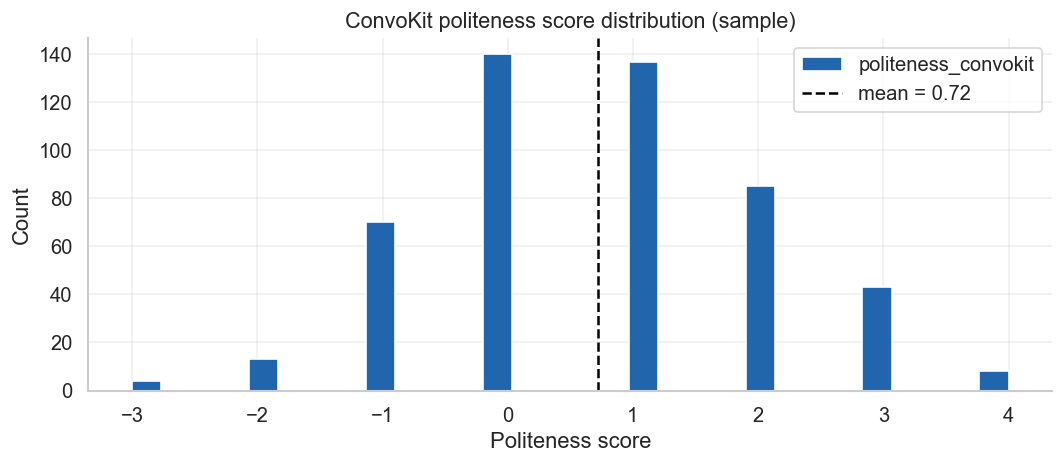

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sample['politeness_convokit'].plot(kind='hist', bins=30, ax=ax, color=BLUE, edgecolor='white')
ax.axvline(sample['politeness_convokit'].mean(), color='black', linestyle='--',
           label=f"mean = {sample['politeness_convokit'].mean():.2f}")
ax.set_title('ConvoKit politeness score distribution (sample)')
ax.set_xlabel('Politeness score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_convokit_distribution.png')
plt.show()

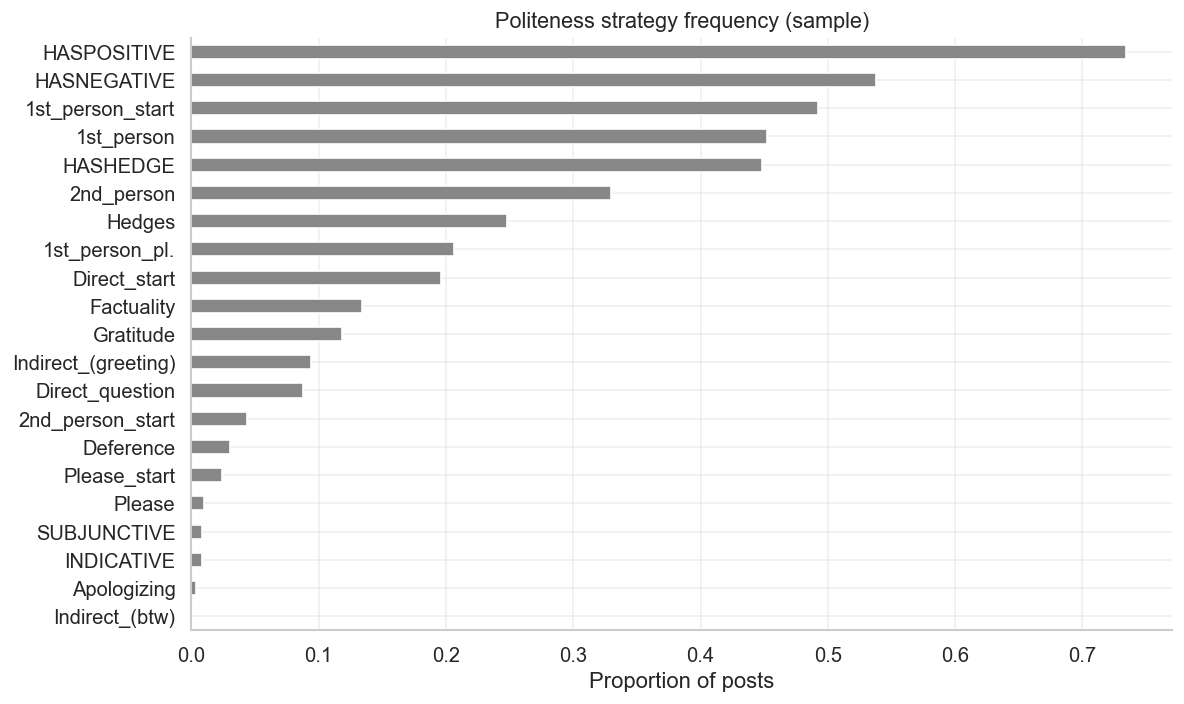

In [9]:
feature_means = convokit_df[feature_cols].mean().sort_values()
feature_means.index = feature_means.index.str.replace('feature_politeness_==','').str.replace('==','')

fig, ax = plt.subplots(figsize=(10, 6))
feature_means.plot(kind='barh', ax=ax, color=GREY)
ax.set_title('Politeness strategy frequency (sample)')
ax.set_xlabel('Proportion of posts')
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_strategy_frequency.png')
plt.show()

## 4. DistilBERT sentiment scoring
DistilBERT is used as a sentiment-based politeness proxy on the sample to compare against ConvoKit scores.

In [10]:
# load DistilBERT sentiment classifier as a politeness proxy
from transformers import pipeline

politeness_pipe = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=-1,
    truncation=True,
    max_length=512
)

test = politeness_pipe("Could you please help me understand this? Thank you!")
print('Test:', test)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Test: [{'label': 'POSITIVE', 'score': 0.9997287392616272}]


In [11]:
# score 500 sample posts with DistilBERT
def score_transformer(texts, batch_size=32):
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        results.extend(politeness_pipe(batch))
    return results

print(f'Scoring {len(sample):,} posts with DistilBERT...')
transformer_results = score_transformer(sample['text_clean'].tolist())

sample['politeness_transformer_label'] = [r['label'] for r in transformer_results]
sample['politeness_transformer_score'] = [r['score'] for r in transformer_results]

print(sample['politeness_transformer_label'].value_counts().to_string())

Scoring 500 posts with DistilBERT...
politeness_transformer_label
NEGATIVE    288
POSITIVE    212


In [12]:
# convert labels to numeric for correlation
sample['politeness_transformer_num'] = (
    sample['politeness_transformer_label']
    .str.upper().map({'POSITIVE': 1.0, 'NEGATIVE': 0.0}).fillna(0.5)
)
print(sample['politeness_transformer_num'].value_counts().to_string())

politeness_transformer_num
0.0    288
1.0    212


## 5. DistilBERT score distribution on sample posts

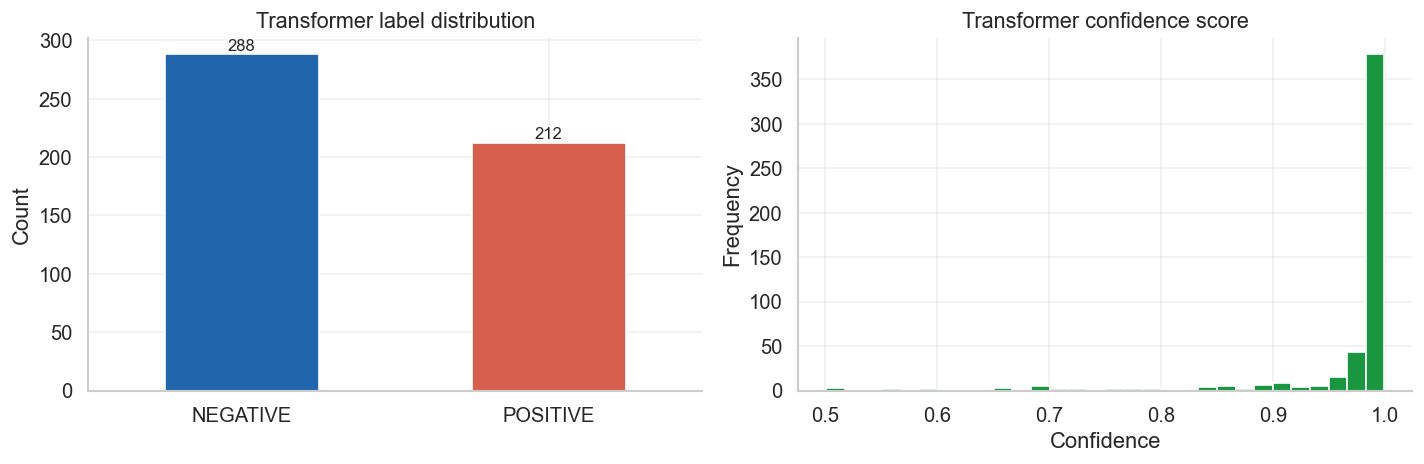

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample['politeness_transformer_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=[BLUE, RED], edgecolor='white')
axes[0].set_title('Transformer label distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=10)

sample['politeness_transformer_score'].plot(
    kind='hist', bins=30, ax=axes[1], color=GREEN, edgecolor='white')
axes[1].set_title('Transformer confidence score')
axes[1].set_xlabel('Confidence')

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_transformer_distribution.png')
plt.show()

## 6. Method comparison and validation
Compare ConvoKit and DistilBERT scores using Spearman correlation

In [14]:
# compare ConvoKit and DistilBERT scores using Spearman correlation
from scipy.stats import spearmanr

ck = sample['politeness_convokit']
sample['politeness_convokit_norm'] = (ck - ck.min()) / (ck.max() - ck.min())

r, p = spearmanr(sample['politeness_convokit_norm'], sample['politeness_transformer_num'])
print(f'Spearman r = {r:.3f} (p = {p:.4f})')

Spearman r = 0.173 (p = 0.0001)


## 7. Manual validation
Inspect the highest and lowest scored posts to sanity check both methods.

In [15]:
# manual validation highest and lowest scored posts by both methods
pd.set_option('display.max_colwidth', 120)
base_cols = ['text_clean', 'politeness_convokit', 'politeness_transformer_label']
cols = base_cols + ['method_disagreement'] if 'method_disagreement' in sample.columns else base_cols

print('Top 5 most polite (ConvoKit):')
display(sample.nlargest(5, 'politeness_convokit')[cols].reset_index(drop=True))

print('Top 5 least polite (ConvoKit):')
display(sample.nsmallest(5, 'politeness_convokit')[cols].reset_index(drop=True))

print('Top 5 most polite (DistilBERT):')
display(sample[sample['politeness_transformer_label']=='POSITIVE'].nlargest(5, 'politeness_transformer_score')[cols].reset_index(drop=True))

print('Top 5 least polite (DistilBERT):')
display(sample[sample['politeness_transformer_label']=='NEGATIVE'].nlargest(5, 'politeness_transformer_score')[cols].reset_index(drop=True))

Top 5 most polite (ConvoKit):


,text_clean,politeness_convokit,politeness_transformer_label
0,"Hello! I think there is a mistake in Quiz 2.4A, question 1. \Analyse\"" (UK) and \""analyze\"" (US) are both correct (p...",4,NEGATIVE
1,"Hello everyone. I'm , working as an Asst.Prof for Finance in India . It's a great pleasure to participate on a such ...",4,POSITIVE
2,**TWO QUESTIONS: 1.Are we supposed to be submitting responses in the box where it asks for it right after the videos...,4,NEGATIVE
3,"I think that we, the students, would be very interested in that information; however, it might open the course to th...",4,NEGATIVE
4,In the lecture it was suggested that for a time series with dependencies between successive data points we could use...,4,NEGATIVE


Top 5 least polite (ConvoKit):


,text_clean,politeness_convokit,politeness_transformer_label
0,"In Chapter 3, slide 22 of the notes, it says that to answer the question of \Is at least one predictor useful?\"", to...",-3,NEGATIVE
1,Number talks help with understanding the concept because they allow you to see other ways of solving a problem. You ...,-3,POSITIVE
2,That's it! As an Elementary Math Specialist I've wondered why I can't get many teachers to change the way they teach...,-3,NEGATIVE
3,"I had the same problem with the first peer reviews I completed; I don't know why. It was discouraging, but additiona...",-3,POSITIVE
4,This foils shows the bias and variance for differing values of lambda. How are these values being calculated?,-2,NEGATIVE


Top 5 most polite (DistilBERT):


,text_clean,politeness_convokit,politeness_transformer_label
0,"Hi everyone happy to be taking this course, agree with the code, and looking forward to the interaction.",2,POSITIVE
1,"Thanks Kristin, this course was really interesting and useful for me, it boosted both style and enthusiasm. It came ...",2,POSITIVE
2,Thank you. Looking forward to fortifying old learning and learning anew.,1,POSITIVE
3,"Hello, Thanks for the opportunity to take part in this course. I'm really enjoying it. Thank you. My best regards to...",2,POSITIVE
4,"I am Dr. , M.D. in Pharmacology. I am from Mumbai. All the best guys!!",1,POSITIVE


Top 5 least polite (DistilBERT):


,text_clean,politeness_convokit,politeness_transformer_label
0,I just posted about the same and then saw your comment. The quiz lacks clarity. Did some of the students actually an...,-1,NEGATIVE
1,"I also think that information is lost if you cancel out the \communication\"" because there is also non-verbal commun...",1,NEGATIVE
2,I found I had to be in chrome Internet explore did not work.,1,NEGATIVE
3,"Hello, Just a guess, but you have a row that is missing data.",1,NEGATIVE
4,I just missed the due date.Because I am busy with some academic matters. Any option for re submission of essay in an...,-1,NEGATIVE


In [16]:
# save top disagreement posts as validation evidence
sample['method_disagreement'] = abs(
    sample['politeness_convokit_norm'] - sample['politeness_transformer_num']
)

top_disagreements = sample.nlargest(15, 'method_disagreement')[[
    'text_clean', 'politeness_convokit',
    'politeness_transformer_label', 'method_disagreement'
]].copy()

pd.set_option('display.max_colwidth', 80)
display(top_disagreements.reset_index(drop=True))

top_disagreements.to_csv(DATA_OUT / 'method_validation_disagreements.csv', index=False)
print('Saved method_validation_disagreements.csv')

,text_clean,politeness_convokit,politeness_transformer_label,method_disagreement
0,"Hello! I think there is a mistake in Quiz 2.4A, question 1. \Analyse\"" (UK) ...",4,NEGATIVE,1.000000
1,**TWO QUESTIONS: 1.Are we supposed to be submitting responses in the box whe...,4,NEGATIVE,1.000000
2,Number talks help with understanding the concept because they allow you to s...,-3,POSITIVE,1.000000
3,"I think that we, the students, would be very interested in that information;...",4,NEGATIVE,1.000000
4,I had the same problem with the first peer reviews I completed; I don't know...,-3,POSITIVE,1.000000
5,In the lecture it was suggested that for a time series with dependencies bet...,4,NEGATIVE,1.000000
6,Thanks for your reaction! I agree with what you say in the first part. Howev...,4,NEGATIVE,1.000000
7,"Hi all, Thanks for the many helpful comments regarding quiz questions. As I'...",4,NEGATIVE,1.000000
8,How impressive that they know about decomposing and making friendly problems...,-2,POSITIVE,0.857143
9,We are all here to learn. Math is a new language. Learning anything new is g...,-2,POSITIVE,0.857143


Saved method_validation_disagreements.csv



## 8. Score full dataset with Convokit

In [17]:
# score all 28,266 posts with ConvoKit
print(f'Scoring {len(df):,} posts...')

ck_results  = df['text_clean'].apply(score_convokit)
ck_full_df  = pd.DataFrame(ck_results.tolist())

pos_cols = [c for c in positive if c in ck_full_df.columns]
neg_cols = [c for c in negative if c in ck_full_df.columns]

df['politeness_score'] = (
    ck_full_df[pos_cols].sum(axis=1) - ck_full_df[neg_cols].sum(axis=1)
)

for col in ck_full_df.columns:
    df[col] = ck_full_df[col].values

print(df['politeness_score'].describe().round(3).to_string())

Scoring 28,266 posts...
count    28266.000
mean         0.797
std          1.355
min         -4.000
25%          0.000
50%          1.000
75%          2.000
max          6.000


In [18]:
# find one example post per feature
feature_cols = [c for c in df.columns if 'feature_politeness' in c]

for feat in feature_cols:
    name     = feat.replace('feature_politeness_==', '').replace('==', '')
    examples = df[df[feat].astype(float) == 1]['text_clean'].dropna()
    short    = examples[examples.str.len() < 150]
    ex       = short.iloc[0] if len(short) > 0 else examples.iloc[0] if len(examples) > 0 else 'none found'
    print(f'{name}:\n  {ex[:140]}\n')

Please:
  If you are not making any mistakes in this class, please talk to me, this is not the right class for you.

Please_start:
  same thing happening to me! I would also like to earn the credit. Please advise.

HASHEDGE:
  Math shouldn't be about right vs. wrong. Math can become fun when it is conceptual and you can adapt it to different situations.

Indirect_(btw):
  Thanks . I will look it up. By the way, do you have any idea how to implement suggestion of incorporating dummy variable. Thanks

Hedges:
  I was impressed by how many different ways people saw these 10 dots. I think it helps students realize there is not just one way to do a pro

Factuality:
  great idea! This idea will really help students to see the investment they are making in learning from their mistakes.

Deference:
  Great ideas. Asking students to illustrate how mistakes can lead to their learning is normalizing and encouraging to others.

Gratitude:
  Thanks for sharing this. I was wondering how to find more

## 9. Save scored dataset

In [19]:
# save scored dataset

for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = df[col].astype(str)

df.to_parquet(DATA_PROCESSED / 'posts_scored.parquet', index=False)
print(f'Saved {len(df):,} posts to posts_scored.parquet')

Saved 28,266 posts to posts_scored.parquet
